# Plot Error Full Grad Correlation

Compare gradient statistics across different INR samplers (`random`, `NMT`, `2d_grid_linear`, `2d_grid_adaptive`, original) evaluated on the same set of checkpoints from a single training run.

In [1]:
%load_ext autoreload
%autoreload 2

## 1. Setup & Imports

In [30]:
from __future__ import annotations

import sys
import re
from pathlib import Path

# Add repo root to sys.path so local modules resolve correctly
REPO_ROOT = Path("../../../").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import copy
import random

import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from torch_geometric.data import Data

# Local utilities from this repo
from gradient_test import (
    compute_sampled_gradients,
    _load_checkpoint,
    _build_graph,
    _apply_sampler_overrides,
    _weighted_mse,
    _call_sampler,
    _set_all_seeds,
    _flatten_gradients,
)
from train_utility_sampling.SamplerWrapper import create_inr_sampler
from utils.load_inr import create_inr_instance

print("Imports OK — repo root:", REPO_ROOT)

Imports OK — repo root: /pscratch/sd/g/gzhao27/INR/INR_SAMPLE


## 2. Define Checkpoint Path & Device

In [31]:
CHECKPOINT_DIR = Path(
    "/pscratch/sd/g/gzhao27/INR/INR_SAMPLE/Results/checkpoints/2026-05-03-05-13-25NS1024_sgd_lrtune_random_re_10000_sampling_2e-3_lr_1e-5_depth_6_t100"
)

assert CHECKPOINT_DIR.is_dir(), f"Checkpoint dir not found: {CHECKPOINT_DIR}"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")
print(f"GPU    : {torch.cuda.get_device_name(0) if DEVICE == 'cuda' else 'N/A'}")

# Collect all numeric step checkpoints and sort them
NUMERIC_RE = re.compile(r"^(\d+)\.pt$")
checkpoint_steps = sorted(
    [(int(m.group(1)), p) for p in CHECKPOINT_DIR.glob("*.pt") if (m := NUMERIC_RE.match(p.name))],
    key=lambda x: x[0],
)
step_list = [s for s, _ in checkpoint_steps]
path_list = [p for _, p in checkpoint_steps]

print(f"\nFound {len(checkpoint_steps)} checkpoints: steps {step_list[:5]} ... {step_list[-3:]}")

Device : cuda
GPU    : NVIDIA A100-PCIE-40GB

Found 99 checkpoints: steps [0, 100, 200, 300, 400] ... [9800, 9900, 9999]


# Sampling comparison show

## 5. Compute Gradient Statistics

For each (sampler, step) pair compute:
- Per-repeat gradient L2 norms
- Mean and std of norms across repeats
- Gradient variance (mean element-wise variance across repeats)
- Average pairwise cosine similarity across repeats
- Orthogonal error relative to the full-graph reference gradient

In [15]:
def avg_pairwise_cosine(grads: list[torch.Tensor]) -> float:
    """Mean pairwise cosine similarity across a list of gradient vectors."""
    if len(grads) < 2:
        return float("nan")
    g = torch.stack(grads, dim=0).float()
    norms = g.norm(dim=1, keepdim=True).clamp_min(1e-12)
    g_norm = g / norms
    cos_mat = g_norm @ g_norm.t()
    idx = torch.triu_indices(len(grads), len(grads), offset=1)
    return float(cos_mat[idx[0], idx[1]].mean().item())


def grad_variance(grads: list[torch.Tensor]) -> float:
    """Mean element-wise variance across repeated gradient vectors."""
    if len(grads) < 2:
        return float("nan")
    g = torch.stack(grads, dim=0).float()
    return float(g.var(dim=0, unbiased=False).mean().item())


def cosine_similarity_to_ref(grads: list[torch.Tensor], ref_grad: torch.Tensor) -> tuple[float, float]:
    """Return mean/std cosine similarity between repeated grads and ref_grad."""
    if not grads or ref_grad.numel() == 0:
        return float("nan"), float("nan")

    ref = ref_grad.float()
    ref_norm = ref.norm().clamp_min(1e-12)

    cos_vals = []
    for g in grads:
        g = g.float()
        g_norm = g.norm().clamp_min(1e-12)
        cos_vals.append(float(torch.dot(g, ref) / (g_norm * ref_norm)))

    cos_arr = np.asarray(cos_vals, dtype=np.float64)
    return float(cos_arr.mean()), float(cos_arr.std())


def orthogonal_error(sample_grads: list[torch.Tensor], ref_grad: torch.Tensor) -> tuple[float, float]:
    """Squared norm of the component of each sample gradient orthogonal to ref_grad."""
    if not sample_grads or ref_grad.numel() == 0:
        return float("nan"), float("nan")
    g = torch.stack(sample_grads, dim=0).float()
    ref = ref_grad.float()
    ref_norm_sq = ref.dot(ref)
    if ref_norm_sq.item() <= 1e-20:
        dist_sq = (g * g).sum(dim=1)
    else:
        proj_coeff = (g @ ref) / ref_norm_sq
        proj = proj_coeff.unsqueeze(1) * ref.unsqueeze(0)
        residual = g - proj
        dist_sq = (residual * residual).sum(dim=1)
    return float(dist_sq.mean().item()), float(dist_sq.std(unbiased=False).item())


# Pre-compute per-step reference (full-graph) gradients from the original checkpoint
print("Computing reference (full-graph) gradients ...")
ref_grads: dict[int, torch.Tensor] = {}
for step, ckpt_path in checkpoint_steps:
    ckpt = _load_checkpoint(ckpt_path)
    cfg = ckpt["cfg"]
    input_dim = int(ckpt.get("input_dim", 2))
    output_dim = int(ckpt.get("output_dim", 1))
    dev = torch.device(DEVICE)

    inr = create_inr_instance(cfg, input_dim, output_dim, dev)
    inr.load_state_dict(ckpt["inr"])
    inr.to(dev).train()
    inr.zero_grad(set_to_none=True)

    graph = _build_graph(ckpt, dev)
    pred = inr(graph.space_emb)
    loss = _weighted_mse(pred, graph.feat, weight=None)
    loss.backward()
    ref_grads[step] = _flatten_gradients(inr).cpu()

print(f"  Reference gradients computed for {len(ref_grads)} steps.")

# Build statistics DataFrame
# rows = []
# for sampler_name, step_grads in results.items():
#     for step, grads in step_grads.items():
#         if not grads:
#             continue

#         norms = [g.norm().item() for g in grads]
#         cos_ref_mean, cos_ref_std = cosine_similarity_to_ref(grads, ref_grads[step])
#         ortho_mean, ortho_std = orthogonal_error(grads, ref_grads[step])

#         rows.append({
#             "sampler": sampler_name,
#             "step": step,
#             "norm_mean": float(np.mean(norms)),
#             "norm_std": float(np.std(norms)),
#             "grad_variance": grad_variance(grads),
#             "avg_pairwise_cosine": avg_pairwise_cosine(grads),
#             "cosine_to_ref_mean": cos_ref_mean,
#             "cosine_to_ref_std": cos_ref_std,
#             "ortho_error_mean": ortho_mean,
#             "ortho_error_std": ortho_std,
#             # mean gradient vector (stored for later similarity analysis)
#             "_mean_grad": torch.stack(grads, dim=0).mean(dim=0),
#         })

# stats_df = pd.DataFrame(rows)
# print(stats_df.drop(columns=["_mean_grad"]).to_string(index=False))

Computing reference (full-graph) gradients ...
  Reference gradients computed for 31 steps.


In [18]:
ref_grads[0].shape

torch.Size([97341])

In [21]:
graph = _build_graph(ckpt, dev)
pred = inr(graph.space_emb)
loss = _weighted_mse(pred, graph.feat, weight=None)
loss.backward()

torch.Size([97341])

Step 4000  |  N = 1,048,576 points  |  subsampling K = 2000
Using pre-computed ref_grad from ref_grads dict.
n_params = 97,341  |  computing per-point gradients for K = 2000 ...
  vmap/grad  500/2000
  vmap/grad  1000/2000
  vmap/grad  1500/2000
  vmap/grad  2000/2000
Per-point grads via torch.func.grad  ✓
correlation  range : [-0.195, 0.326]
projection   range : [-340.872, 2031.338]
loss         range : [5.9605e-08, 7.6625e+00]


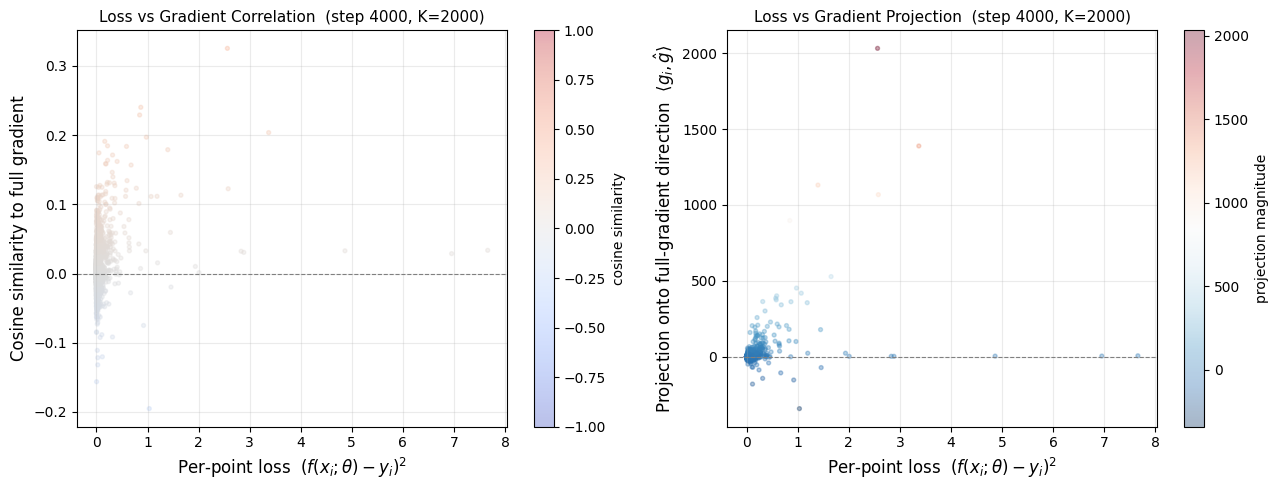

Saved → /pscratch/sd/g/gzhao27/INR/INR_SAMPLE/Results/latex/paper_data/loss_vs_grad_correlation.pdf


In [22]:

# ── Per-point loss gradient vs full gradient: correlation & projection scatter ──
#
# For a chosen checkpoint step:
#   1. Load model + full graph.
#   2. Compute full-data gradient  g_full  (mean MSE over all N points).
#   3. For a random subset of K points, compute per-point gradient
#          g_i = ∇_θ  (f(x_i; θ) − y_i)²
#   4. correlation_i  = cosine(g_i, g_full)
#      projection_i   = dot(g_i, g_full̂)   (scalar projection onto full-grad direction)
#   5. Scatter:  per-point loss  vs  correlation / projection.

# ── Config ────────────────────────────────────────────────────────────────────
ANALYZE_STEP = checkpoint_steps[-1][0]   # e.g. step 4000; change as desired
MAX_POINTS   = 2000                       # subsample size (full ~1M for NS1024)
SEED         = 42

# ── 1. Load checkpoint, model, graph ─────────────────────────────────────────
_ckpt_path = dict(checkpoint_steps)[ANALYZE_STEP]
_ckpt      = _load_checkpoint(_ckpt_path)
_cfg       = _ckpt["cfg"]
_input_dim  = int(_ckpt.get("input_dim",  2))
_output_dim = int(_ckpt.get("output_dim", 1))
_dev        = torch.device(DEVICE)

_inr = create_inr_instance(_cfg, _input_dim, _output_dim, _dev)
_inr.load_state_dict(_ckpt["inr"])
_inr.to(_dev)

_graph = _build_graph(_ckpt, _dev)
N      = _graph.feat.shape[0]
print(f"Step {ANALYZE_STEP}  |  N = {N:,} points  |  subsampling K = {MAX_POINTS}")

# ── 2. Full gradient (use pre-computed ref_grads if available, else recompute) ─
if ANALYZE_STEP in ref_grads:
    g_full_cpu = ref_grads[ANALYZE_STEP].float().cpu()
    print("Using pre-computed ref_grad from ref_grads dict.")
else:
    _inr.train()
    _inr.zero_grad(set_to_none=True)
    _pred_all = _inr(_graph.space_emb)
    _loss_all = _weighted_mse(_pred_all, _graph.feat, weight=None)
    _loss_all.backward()
    g_full_cpu = _flatten_gradients(_inr).float().cpu()
    print("Recomputed ref_grad from full forward+backward pass.")

g_full_norm = g_full_cpu.norm().clamp_min(1e-12)
g_full_hat  = g_full_cpu / g_full_norm   # unit vector in full-gradient direction

# ── 3. Per-point loss (no grad needed) ───────────────────────────────────────
_inr.eval()
with torch.no_grad():
    _pred_full = _inr(_graph.space_emb)                       # (N, out)
point_losses_all = (_pred_full - _graph.feat).pow(2).mean(dim=1)  # (N,)

# ── 4. Subsample K points ─────────────────────────────────────────────────────
_set_all_seeds(SEED)
K         = min(MAX_POINTS, N)
_idx      = torch.randperm(N, device=_dev)[:K]
_coords_k = _graph.space_emb[_idx]   # (K, d)
_feat_k   = _graph.feat[_idx]        # (K, out)
losses_k  = point_losses_all[_idx].cpu().numpy()   # (K,)

# ── 5. Per-point gradients ────────────────────────────────────────────────────
# Strategy A: torch.func vmap (PyTorch >= 2.0, memory-efficient)
# Strategy B: loop of individual backward passes (always works)

n_params = g_full_cpu.numel()
print(f"n_params = {n_params:,}  |  computing per-point gradients for K = {K} ...")

_per_pt_grads = None  # will be (K, n_params) float CPU tensor

try:
    from torch.func import vmap, grad, functional_call  # noqa: F401

    # Only include parameters that participate in the unmodulated forward pass
    # (same set collected by _flatten_gradients: excludes modulation_net params
    #  which receive grad=None when Siren.forward() is used, not the modulated path)
    _params_dict  = {k: v for k, v in _inr.named_parameters()
                     if v.requires_grad and not k.startswith('modulation_net')}
    _buffers_dict = dict(_inr.named_buffers())

    def _loss_single_fn(params, x, y):
        pred = functional_call(_inr, params, (x.unsqueeze(0),), kwargs={})
        return (pred - y.unsqueeze(0)).pow(2).mean()

    _grad_fn = grad(_loss_single_fn)

    _raw_rows = []
    for i in range(K):
        _g = _grad_fn(_params_dict, _coords_k[i], _feat_k[i])
        _raw_rows.append(torch.cat([v.reshape(-1) for v in _g.values()]).detach().cpu())
        if (i + 1) % 500 == 0:
            print(f"  vmap/grad  {i+1}/{K}")

    _per_pt_grads = torch.stack(_raw_rows, dim=0)   # (K, n_params)
    print("Per-point grads via torch.func.grad  ✓")

except Exception as _e_func:
    print(f"torch.func path failed ({_e_func}); using loop backward ...")
    _inr.train()
    _raw_rows = []
    for i in range(K):
        _inr.zero_grad(set_to_none=True)
        _pred_i = _inr(_coords_k[i : i + 1])
        _loss_i = (_pred_i - _feat_k[i : i + 1]).pow(2).mean()
        _loss_i.backward()
        _raw_rows.append(_flatten_gradients(_inr).float().cpu())
        if (i + 1) % 500 == 0:
            print(f"  loop bwd  {i+1}/{K}")
    _per_pt_grads = torch.stack(_raw_rows, dim=0)   # (K, n_params)
    print("Per-point grads via loop backward  ✓")

# ── 6. Correlation & projection ───────────────────────────────────────────────
_pg = _per_pt_grads.float()                                   # (K, n_params)
_pg_norms = _pg.norm(dim=1).clamp_min(1e-12)                  # (K,)

# cosine similarity (correlation) to full gradient
correlations = (_pg @ g_full_cpu / (_pg_norms * g_full_norm)).numpy()  # (K,)

# scalar projection onto full-gradient direction
projections  = (_pg @ g_full_hat).numpy()                      # (K,)

print(f"correlation  range : [{correlations.min():.3f}, {correlations.max():.3f}]")
print(f"projection   range : [{projections.min():.3f}, {projections.max():.3f}]")
print(f"loss         range : [{losses_k.min():.4e}, {losses_k.max():.4e}]")

# ── 7. Scatter plots ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# — Left: loss vs cosine correlation —
ax = axes[0]
sc = ax.scatter(losses_k, correlations, s=8, alpha=0.35, c=correlations,
                cmap="coolwarm", vmin=-1, vmax=1, rasterized=True)
fig.colorbar(sc, ax=ax, label="cosine similarity")
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.set_xlabel(r"Per-point loss  $(f(x_i;\theta)-y_i)^2$", fontsize=12)
ax.set_ylabel("Cosine similarity to full gradient", fontsize=12)
ax.set_title(f"Loss vs Gradient Correlation  (step {ANALYZE_STEP}, K={K})", fontsize=11)
ax.grid(True, alpha=0.25)

# — Right: loss vs projection magnitude —
ax = axes[1]
sc2 = ax.scatter(losses_k, projections, s=8, alpha=0.35, c=projections,
                 cmap="RdBu_r", rasterized=True)
fig.colorbar(sc2, ax=ax, label="projection magnitude")
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.set_xlabel(r"Per-point loss  $(f(x_i;\theta)-y_i)^2$", fontsize=12)
ax.set_ylabel(r"Projection onto full-gradient direction  $\langle g_i,\hat{g}\rangle$", fontsize=12)
ax.set_title(f"Loss vs Gradient Projection  (step {ANALYZE_STEP}, K={K})", fontsize=11)
ax.grid(True, alpha=0.25)

plt.tight_layout()
_out_pdf = Path(REPO_ROOT) / "Results" / "latex" / "paper_data" / "loss_vs_grad_correlation.pdf"
plt.savefig(_out_pdf, bbox_inches="tight", dpi=150)
plt.show()
print(f"Saved → {_out_pdf}")


In [13]:
total_params = sum(p.numel() for p in inr.parameters())
total_params

296516

In [14]:
for name, param in inr.named_parameters():
    print(f"{name}: {'frozen' if not param.requires_grad else 'trainable'}")

net.0.linear.weight: trainable
net.0.linear.bias: trainable
net.1.linear.weight: trainable
net.1.linear.bias: trainable
net.2.linear.weight: trainable
net.2.linear.bias: trainable
net.3.linear.weight: trainable
net.3.linear.bias: trainable
net.4.linear.weight: trainable
net.4.linear.bias: trainable
last_layer.linear.weight: trainable
last_layer.linear.bias: trainable
modulation_net.net.weight: trainable
modulation_net.net.bias: trainable


In [9]:
checkpoint_steps[3]

(300,
 PosixPath('/pscratch/sd/g/gzhao27/INR/INR_SAMPLE/Results/checkpoints/2026-04-18-20-53-04NS1024_single_random_re_10000_sampling_2e-3_lr_1e-4_depth_6_t100/300.pt'))

## 8. Gradient Variance vs Residual Variance Correlation

Compare cell-wise gradient variance (from `cell_grad_variance_estimate_with_jacrev`) 
with residual variance (from `cell_sqrt_loss_variance_estimate_with_random_sampling`).
This helps understand whether gradient complexity correlates with residual error magnitude.

In [32]:
# ── Config ────────────────────────────────────────────────────────────────────
ANALYZE_STEP_VAR = checkpoint_steps[7][0]   # Use selected checkpoint
GRID_SIZE = 16
SEED_VAR = 42
GRAD_VAR_SAMPLES_PER_CELL = 64
RESIDUAL_VAR_SAMPLES_PER_CELL = 64

_set_all_seeds(SEED_VAR)

# ── 1. Load checkpoint, model, graph ──────────────────────────────────────────
_ckpt_path_var = dict(checkpoint_steps)[ANALYZE_STEP_VAR]
_ckpt_var = _load_checkpoint(_ckpt_path_var)
_cfg_var = _ckpt_var["cfg"]
_input_dim_var = int(_ckpt_var.get("input_dim", 2))
_output_dim_var = int(_ckpt_var.get("output_dim", 1))
_dev_var = torch.device(DEVICE)

_inr_var = create_inr_instance(_cfg_var, _input_dim_var, _output_dim_var, _dev_var)
_inr_var.load_state_dict(_ckpt_var["inr"])
_inr_var.to(_dev_var).eval()

_graph_var = _build_graph(_ckpt_var, _dev_var)
H_var = _graph_var.cor.max().item() + 1
N_var = _graph_var.feat.shape[0]
print(f"Step {ANALYZE_STEP_VAR}  |  Image size: {H_var}x{H_var}  |  Total points: {N_var}")

# ── 2. Create a grid decomposition ────────────────────────────────────────────
cell_size = H_var // GRID_SIZE
cells_list = []

for r_s in range(0, H_var, cell_size):
    for c_s in range(0, H_var, cell_size):
        r_e = min(r_s + cell_size - 1, H_var - 1)
        c_e = min(c_s + cell_size - 1, H_var - 1)
        cells_list.append(torch.tensor([r_s, r_e, c_s, c_e], dtype=torch.long))

cell_cor_range_var = torch.stack(cells_list)
print(f"Created {len(cells_list)} cells with grid size ~{cell_size}x{cell_size}")

# ── 3. Compute sampling-based gradient variance ───────────────────────────────
print("Computing cell gradient variance with random sampling...")
from train_utility_sampling.taylor_estimation import (
    cell_grad_variance_estimate_with_random_sampling,
    cell_sqrt_loss_variance_estimate_with_random_sampling,
)

grad_var = cell_grad_variance_estimate_with_random_sampling(
    cell_cor_range_var,
    _graph_var,
    _inr_var,
    _dev_var,
    max_samples_per_cell=GRAD_VAR_SAMPLES_PER_CELL,
)
print(f"  Grad var shape: {grad_var.shape}")
print(f"  Grad var range: [{grad_var.min():.3e}, {grad_var.max():.3e}]")

# ── 4. Compute residual variance ──────────────────────────────────────────────
print("Computing cell residual variance...")
residual_var = cell_sqrt_loss_variance_estimate_with_random_sampling(
    cell_cor_range_var,
    _graph_var,
    _inr_var,
    _dev_var,
    max_samples_per_cell=RESIDUAL_VAR_SAMPLES_PER_CELL,
)
print(f"  Residual var shape: {residual_var.shape}")
print(f"  Residual var range: [{residual_var.min():.3e}, {residual_var.max():.3e}]")

# Move to CPU for analysis (detach to remove grad tracking)
grad_var_np = grad_var.detach().cpu().numpy()
residual_var_np = residual_var.detach().cpu().numpy()

print("\nStatistics:")
print(f"  Gradient variance   - mean: {grad_var_np.mean():.3e}, std: {grad_var_np.std():.3e}")
print(f"  Residual variance   - mean: {residual_var_np.mean():.3e}, std: {residual_var_np.std():.3e}")

Step 700  |  Image size: 1024x1024  |  Total points: 1048576
Created 256 cells with grid size ~64x64
Computing cell gradient variance with random sampling...
  Grad var shape: torch.Size([256])
  Grad var range: [7.157e+04, 1.172e+08]
Computing cell residual variance...
  Residual var shape: torch.Size([256])
  Residual var range: [1.533e-02, 8.029e+00]

Statistics:
  Gradient variance   - mean: 7.420e+06, std: 1.203e+07
  Residual variance   - mean: 5.347e-01, std: 1.004e+00


Correlation Analysis (log-space):
  Pearson correlation:  r = 0.6065, p-value = 4.192e-27
  Spearman correlation: ρ = 0.6488, p-value = 5.635e-32

Correlation Analysis (linear space):
  Pearson correlation:  r = 0.3647, p-value = 1.792e-09
  Spearman correlation: ρ = 0.6488, p-value = 5.635e-32


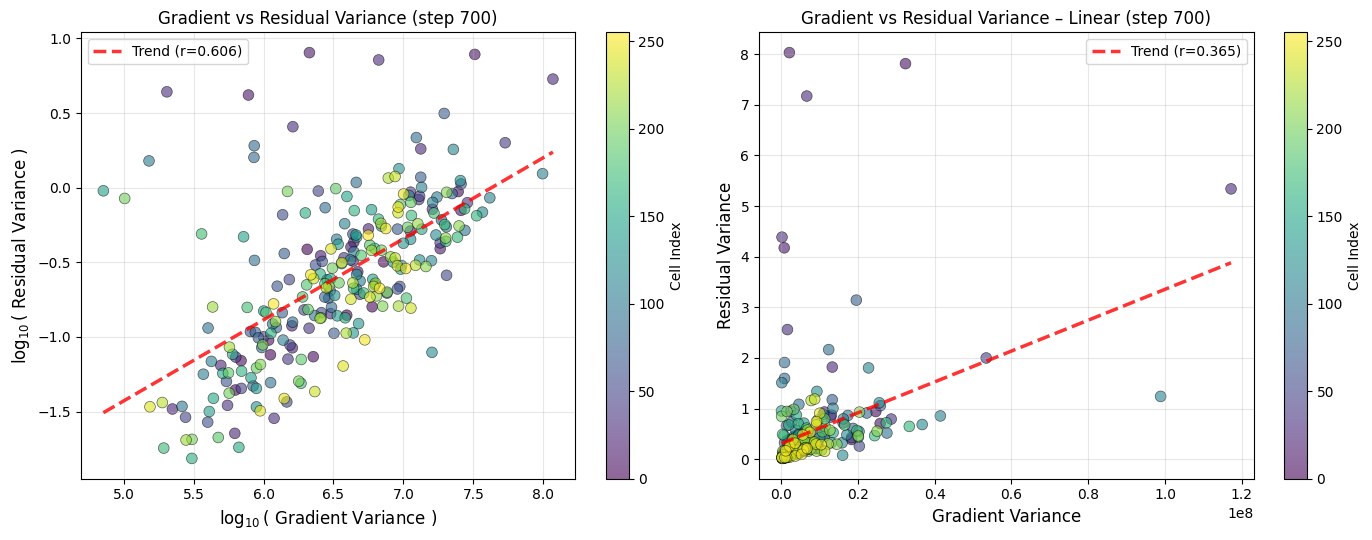


Saved → /pscratch/sd/g/gzhao27/INR/INR_SAMPLE/Results/latex/paper_data/grad_vs_residual_variance_correlation.pdf


In [33]:
# ── 5. Compute correlation metrics ────────────────────────────────────────────
from scipy.stats import pearsonr, spearmanr

# Log-space correlation (often more meaningful for variance metrics)
grad_var_log = np.log10(grad_var_np.clip(min=1e-12))
residual_var_log = np.log10(residual_var_np.clip(min=1e-12))

pearson_r, pearson_p = pearsonr(grad_var_log, residual_var_log)
spearman_r, spearman_p = spearmanr(grad_var_log, residual_var_log)

print("Correlation Analysis (log-space):")
print(f"  Pearson correlation:  r = {pearson_r:.4f}, p-value = {pearson_p:.3e}")
print(f"  Spearman correlation: ρ = {spearman_r:.4f}, p-value = {spearman_p:.3e}")

# Linear space
pearson_r_lin, pearson_p_lin = pearsonr(grad_var_np, residual_var_np)
spearman_r_lin, spearman_p_lin = spearmanr(grad_var_np, residual_var_np)
print("\nCorrelation Analysis (linear space):")
print(f"  Pearson correlation:  r = {pearson_r_lin:.4f}, p-value = {pearson_p_lin:.3e}")
print(f"  Spearman correlation: ρ = {spearman_r_lin:.4f}, p-value = {spearman_p_lin:.3e}")

# ── 6. Create comparison figure ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# — Left: Gradient variance vs Residual variance (log-log) —
ax = axes[0]
# Create colormap based on cell location for better visualization
cell_indices = np.arange(len(grad_var_np))
sc = ax.scatter(grad_var_log, residual_var_log, s=60, alpha=0.6, c=cell_indices,
                cmap="viridis", edgecolors="black", linewidth=0.5, rasterized=True)
fig.colorbar(sc, ax=ax, label="Cell Index")

# Add trend line
z = np.polyfit(grad_var_log, residual_var_log, 1)
p = np.poly1d(z)
x_trend = np.linspace(grad_var_log.min(), grad_var_log.max(), 100)
ax.plot(x_trend, p(x_trend), "r--", lw=2.5, alpha=0.8, label=f"Trend (r={pearson_r:.3f})")

ax.set_xlabel(r"$\log_{10}($ Gradient Variance $)$", fontsize=12)
ax.set_ylabel(r"$\log_{10}($ Residual Variance $)$", fontsize=12)
ax.set_title(f"Gradient vs Residual Variance (step {ANALYZE_STEP_VAR})", fontsize=12)
ax.legend(loc="best", fontsize=10)
ax.grid(True, alpha=0.3)

# — Right: Linear space scatter —
ax = axes[1]
sc2 = ax.scatter(grad_var_np, residual_var_np, s=60, alpha=0.6, c=cell_indices,
                 cmap="viridis", edgecolors="black", linewidth=0.5, rasterized=True)
fig.colorbar(sc2, ax=ax, label="Cell Index")

# Add trend line in linear space
z_lin = np.polyfit(grad_var_np, residual_var_np, 1)
p_lin = np.poly1d(z_lin)
x_trend_lin = np.linspace(grad_var_np.min(), grad_var_np.max(), 100)
ax.plot(x_trend_lin, p_lin(x_trend_lin), "r--", lw=2.5, alpha=0.8, 
        label=f"Trend (r={pearson_r_lin:.3f})")

ax.set_xlabel("Gradient Variance", fontsize=12)
ax.set_ylabel("Residual Variance", fontsize=12)
ax.set_title(f"Gradient vs Residual Variance – Linear (step {ANALYZE_STEP_VAR})", fontsize=12)
ax.legend(loc="best", fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
_out_pdf_var = Path(REPO_ROOT) / "Results" / "latex" / "paper_data" / "grad_vs_residual_variance_correlation.pdf"
plt.savefig(_out_pdf_var, bbox_inches="tight", dpi=150)
plt.show()
print(f"\nSaved → {_out_pdf_var}")


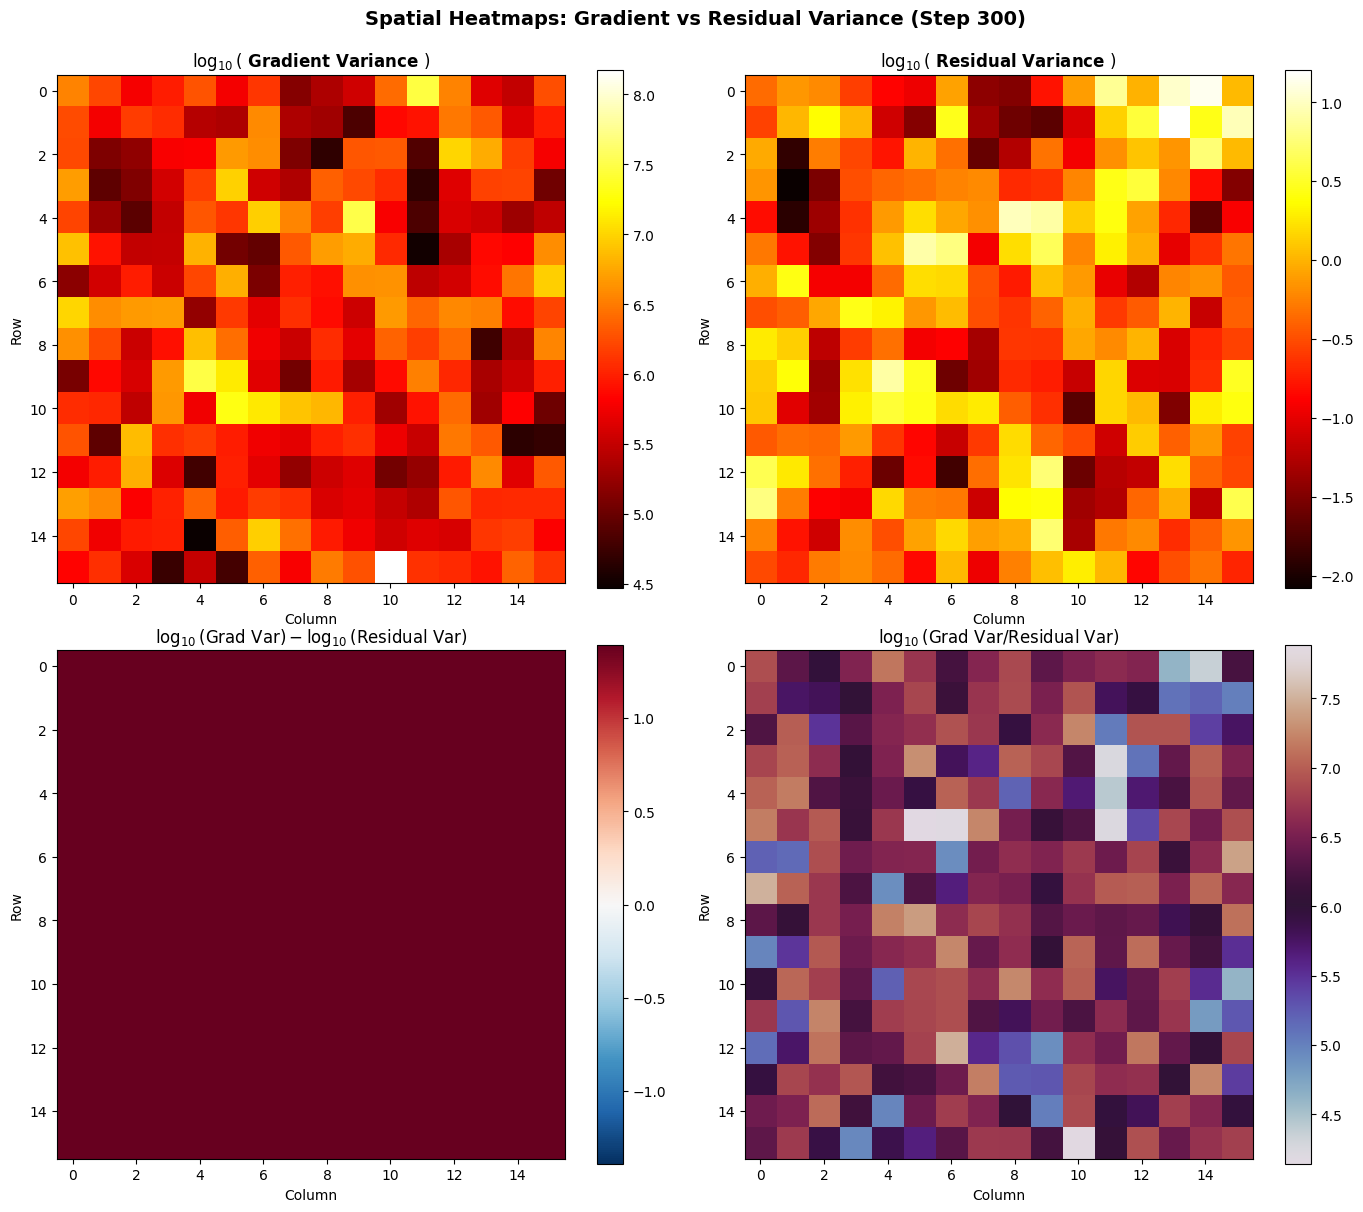

Saved → /pscratch/sd/g/gzhao27/INR/INR_SAMPLE/Results/latex/paper_data/grad_vs_residual_variance_heatmaps.pdf


In [12]:
# ── 7. Create spatial heatmap visualization ─────────────────────────────────────
# Reshape cell variances back to 2D grid for spatial visualization
n_cells_per_side = GRID_SIZE
if len(cells_list) == n_cells_per_side ** 2:
    grad_var_2d = grad_var_np.reshape(n_cells_per_side, n_cells_per_side)
    residual_var_2d = residual_var_np.reshape(n_cells_per_side, n_cells_per_side)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    
    # — Top-left: Gradient variance heatmap —
    ax = axes[0, 0]
    im1 = ax.imshow(np.log10(grad_var_2d.clip(min=1e-12)), cmap="hot", origin="upper")
    ax.set_title(r"$\log_{10}($ Gradient Variance $)$", fontsize=12, fontweight="bold")
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")
    plt.colorbar(im1, ax=ax)
    
    # — Top-right: Residual variance heatmap —
    ax = axes[0, 1]
    im2 = ax.imshow(np.log10(residual_var_2d.clip(min=1e-12)), cmap="hot", origin="upper")
    ax.set_title(r"$\log_{10}($ Residual Variance $)$", fontsize=12, fontweight="bold")
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")
    plt.colorbar(im2, ax=ax)
    
    # — Bottom-left: Difference map (grad - residual in log space) —
    ax = axes[1, 0]
    diff_2d = np.log10(grad_var_2d.clip(min=1e-12)) - np.log10(residual_var_2d.clip(min=1e-12))
    im3 = ax.imshow(diff_2d, cmap="RdBu_r", origin="upper", vmin=-diff_2d.std()*2, vmax=diff_2d.std()*2)
    ax.set_title(r"$\log_{10}(\text{Grad Var}) - \log_{10}(\text{Residual Var})$", fontsize=12, fontweight="bold")
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")
    plt.colorbar(im3, ax=ax)
    
    # — Bottom-right: Ratio map —
    ax = axes[1, 1]
    ratio_2d = grad_var_2d / residual_var_2d.clip(min=1e-12)
    im4 = ax.imshow(np.log10(ratio_2d.clip(min=1e-12)), cmap="twilight", origin="upper")
    ax.set_title(r"$\log_{10}(\text{Grad Var} / \text{Residual Var})$", fontsize=12, fontweight="bold")
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")
    plt.colorbar(im4, ax=ax)
    
    plt.suptitle(f"Spatial Heatmaps: Gradient vs Residual Variance (Step {ANALYZE_STEP_VAR})", 
                 fontsize=14, fontweight="bold", y=1.00)
    plt.tight_layout()
    
    _out_pdf_heatmap = Path(REPO_ROOT) / "Results" / "latex" / "paper_data" / "grad_vs_residual_variance_heatmaps.pdf"
    plt.savefig(_out_pdf_heatmap, bbox_inches="tight", dpi=150)
    plt.show()
    print(f"Saved → {_out_pdf_heatmap}")
else:
    print(f"Warning: Expected {n_cells_per_side**2} cells but got {len(cells_list)}")


## 9. Paper Metrics: Rank Correlation & Top-K Overlap

For each selected training checkpoint, we compute two metrics that justify using
$S_{r,k}^2$ (residual variance) as a surrogate for $S_{g,k}^2$ (gradient variance):

1. **Rank correlation** – Spearman's ρ between per-cell gradient variance and residual variance scores.
2. **Top-K overlap ratio** – fraction of the top-K highest-gradient-variance cells that also appear in the top-K highest-residual-variance cells, for K ∈ {5 %, 10 %, 20 %, 30 %, 50 %}.

The random baseline for overlap at top-K% is K% (random chance), so values well above it confirm that residual variance is a reliable proxy.

In [34]:

from scipy.stats import spearmanr as _spearmanr
from train_utility_sampling.taylor_estimation import (
    cell_grad_variance_estimate_with_random_sampling,
    cell_sqrt_loss_variance_estimate_with_random_sampling,
)

# ── Config ────────────────────────────────────────────────────────────────────
METRIC_CELL_SIZES     = [16, 32]       # cell side lengths in pixels to compare
METRIC_N_CELLS        = 256            # random cells to draw *per* cell size
METRIC_GRAD_SAMPLES   = 16             # per-cell backward passes for S_g
METRIC_RESIDUAL_SAMPLES = 32           # per-cell forward passes for S_r
METRIC_SEED = 42
TOP_K_FRACS = [0.05, 0.10, 0.20, 0.30, 0.50]

# Select ~8 evenly-spaced checkpoints across training
_n_ckpts = len(checkpoint_steps)
_stride  = max(1, _n_ckpts // 8)
selected_for_metrics = checkpoint_steps[::_stride]
print(f"Evaluating {len(selected_for_metrics)} checkpoints: "
      f"{[s for s, _ in selected_for_metrics]}")

# ── Build random cell grids from the first checkpoint's graph ─────────────────
_set_all_seeds(METRIC_SEED)
_c0   = _load_checkpoint(selected_for_metrics[0][1])
_g0   = _build_graph(_c0, torch.device(DEVICE))
_H0   = int(_g0.cor.max().item() + 1)

rng_cells = np.random.default_rng(METRIC_SEED)

cell_range_by_size = {}   # cell_size -> [N_cells, 4] LongTensor
for cs in METRIC_CELL_SIZES:
    _cells = []
    # Sample random top-left corners; clip so cell stays inside [0, H0-1]
    r_starts = rng_cells.integers(0, max(_H0 - cs + 1, 1), size=METRIC_N_CELLS)
    c_starts = rng_cells.integers(0, max(_H0 - cs + 1, 1), size=METRIC_N_CELLS)
    for rs, css in zip(r_starts, c_starts):
        re = min(int(rs) + cs - 1, _H0 - 1)
        ce = min(int(css) + cs - 1, _H0 - 1)
        _cells.append(torch.tensor([int(rs), re, int(css), ce], dtype=torch.long))
    cell_range_by_size[cs] = torch.stack(_cells)
    n_cells = len(_cells)
    K_vals_for = [max(1, int(f * n_cells)) for f in TOP_K_FRACS]
    print(f"  Cell size {cs}×{cs}: {n_cells} random cells  |  K = {K_vals_for}")

# ── Sweep checkpoints ─────────────────────────────────────────────────────────
metric_rows_by_size = {cs: [] for cs in METRIC_CELL_SIZES}

for step, ckpt_path in selected_for_metrics:
    print(f"\n  step {step:>5}", flush=True)
    _ck    = _load_checkpoint(ckpt_path)
    _inr_m = create_inr_instance(
        _ck["cfg"], int(_ck.get("input_dim", 2)), int(_ck.get("output_dim", 1)),
        torch.device(DEVICE)
    )
    _inr_m.load_state_dict(_ck["inr"])
    _inr_m.to(DEVICE).eval()
    _graph_m = _build_graph(_ck, torch.device(DEVICE))

    for cs in METRIC_CELL_SIZES:
        cell_range_m = cell_range_by_size[cs]
        n_cells_m    = len(cell_range_m)
        K_vals        = [max(1, int(f * n_cells_m)) for f in TOP_K_FRACS]

        # S_g,k^2
        _set_all_seeds(METRIC_SEED)
        gv = cell_grad_variance_estimate_with_random_sampling(
            cell_range_m, _graph_m, _inr_m, DEVICE,
            max_samples_per_cell=METRIC_GRAD_SAMPLES,
        ).detach().cpu().numpy()

        # S_r,k^2
        rv = cell_sqrt_loss_variance_estimate_with_random_sampling(
            cell_range_m, _graph_m, _inr_m, DEVICE,
            max_samples_per_cell=METRIC_RESIDUAL_SAMPLES,
        ).detach().cpu().numpy()

        # 1. Rank correlation
        rho, rho_p = _spearmanr(gv, rv)

        # 2. Top-K overlap
        row = {"step": step, "cell_size": cs,
               "spearman_rho": float(rho), "spearman_p": float(rho_p)}
        overlap_strs = []
        for k, f in zip(K_vals, TOP_K_FRACS):
            top_g   = set(np.argsort(gv)[::-1][:k].tolist())
            top_r   = set(np.argsort(rv)[::-1][:k].tolist())
            overlap = len(top_g & top_r) / k
            row[f"topk_{int(f*100):02d}pct"] = float(overlap)
            overlap_strs.append(f"top-{int(f*100)}%={overlap:.2f}")

        metric_rows_by_size[cs].append(row)
        print(f"    [{cs}×{cs}]  ρ={rho:.3f}  |  " + "  ".join(overlap_strs))

metrics_dfs = {cs: pd.DataFrame(rows) for cs, rows in metric_rows_by_size.items()}

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n" + "─"*85)
print("PAPER METRICS SUMMARY (by cell size)")
print("─"*85)
print(f"{'Metric':<40}  {'Mean':>8}  {'Std':>8}  {'Min':>8}  {'Max':>8}")
print("─"*85)
for cs in METRIC_CELL_SIZES:
    df = metrics_dfs[cs]
    print(f"\n  Cell size {cs}×{cs}")
    rho_col = df["spearman_rho"]
    print(f"  {'Spearman ρ':<38}  {rho_col.mean():8.3f}  {rho_col.std():8.3f}"
          f"  {rho_col.min():8.3f}  {rho_col.max():8.3f}")
    for f in TOP_K_FRACS:
        col = f"topk_{int(f*100):02d}pct"
        v   = df[col]
        lbl = f"  Top-{int(f*100):2d}% overlap (random={f:.2f})"
        print(f"  {lbl:<38}  {v.mean():8.3f}  {v.std():8.3f}"
              f"  {v.min():8.3f}  {v.max():8.3f}")
print("─"*85)


Evaluating 9 checkpoints: [0, 1200, 2400, 3600, 4800, 6000, 7200, 8500, 9800]
  Cell size 16×16: 256 random cells  |  K = [12, 25, 51, 76, 128]
  Cell size 32×32: 256 random cells  |  K = [12, 25, 51, 76, 128]

  step     0
    [16×16]  ρ=0.747  |  top-5%=0.58  top-10%=0.60  top-20%=0.67  top-30%=0.72  top-50%=0.80
    [32×32]  ρ=0.689  |  top-5%=0.50  top-10%=0.52  top-20%=0.55  top-30%=0.70  top-50%=0.75

  step  1200
    [16×16]  ρ=0.785  |  top-5%=0.50  top-10%=0.52  top-20%=0.65  top-30%=0.82  top-50%=0.83
    [32×32]  ρ=0.780  |  top-5%=0.58  top-10%=0.60  top-20%=0.73  top-30%=0.74  top-50%=0.84

  step  2400
    [16×16]  ρ=0.802  |  top-5%=0.58  top-10%=0.64  top-20%=0.75  top-30%=0.84  top-50%=0.84
    [32×32]  ρ=0.829  |  top-5%=0.33  top-10%=0.52  top-20%=0.78  top-30%=0.82  top-50%=0.83

  step  3600
    [16×16]  ρ=0.792  |  top-5%=0.33  top-10%=0.56  top-20%=0.71  top-30%=0.83  top-50%=0.80
    [32×32]  ρ=0.851  |  top-5%=0.25  top-10%=0.40  top-20%=0.67  top-30%=0.82  top

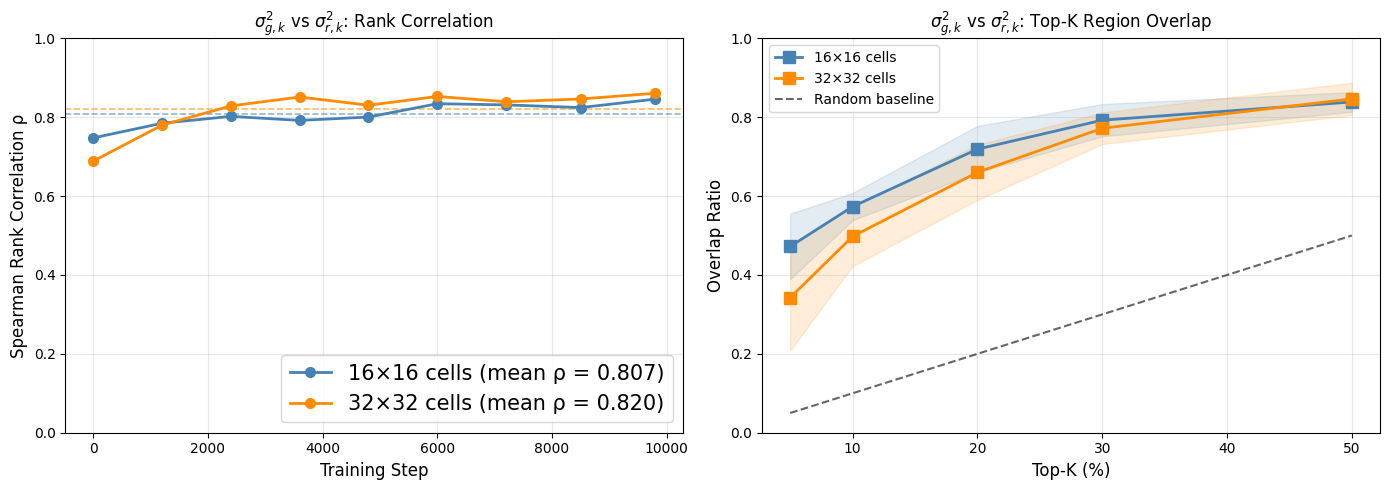

Saved → /pscratch/sd/g/gzhao27/INR/INR_SAMPLE/Results/latex/paper_data/proxy_metrics_rank_topk.pdf

LaTeX table rows (one per cell size):
NS1024 (16px) & 0.807 $\pm$ 0.031 & 0.472 $\pm$ 0.083 & 0.573 $\pm$ 0.035 & 0.719 $\pm$ 0.059 & 0.792 $\pm$ 0.041 & 0.839 $\pm$ 0.025 \\
NS1024 (32px) & 0.820 $\pm$ 0.054 & 0.343 $\pm$ 0.135 & 0.498 $\pm$ 0.075 & 0.660 $\pm$ 0.070 & 0.772 $\pm$ 0.040 & 0.846 $\pm$ 0.041 \\


In [35]:

# ── Figure: rank correlation & top-K overlap vs training step (both cell sizes) ─
_colors = {16: "steelblue", 32: "darkorange"}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# — Left: Spearman ρ vs step —
ax = axes[0]
for cs in METRIC_CELL_SIZES:
    df       = metrics_dfs[cs]
    steps_arr = df["step"].to_numpy()
    rho_arr  = df["spearman_rho"].to_numpy()
    mean_rho = rho_arr.mean()
    color    = _colors[cs]
    ax.plot(steps_arr, rho_arr, "o-", lw=2, ms=7, color=color,
            label=f"{cs}×{cs} cells (mean ρ = {mean_rho:.3f})", zorder=3)
    ax.axhline(mean_rho, color=color, lw=1.2, ls="--", alpha=0.6, zorder=2)

ax.set_xlabel("Training Step", fontsize=12)
ax.set_ylabel("Spearman Rank Correlation ρ", fontsize=12)
ax.set_title(r"$\sigma_{g,k}^2$ vs $\sigma_{r,k}^2$: Rank Correlation", fontsize=12)
ax.set_ylim(0, 1)
ax.legend(fontsize=15, loc="lower right")
ax.grid(True, alpha=0.3)

# — Right: Top-K overlap vs K fraction (mean ± std across steps) —
ax = axes[1]
x_pct = [int(f * 100) for f in TOP_K_FRACS]
topk_cols = [f"topk_{int(f*100):02d}pct" for f in TOP_K_FRACS]

for cs in METRIC_CELL_SIZES:
    df       = metrics_dfs[cs]
    color    = _colors[cs]
    means    = [df[c].mean() for c in topk_cols]
    stds     = [df[c].std()  for c in topk_cols]
    ax.plot(x_pct, means, "s-", lw=2, ms=8, color=color,
            label=f"{cs}×{cs} cells", zorder=3)
    ax.fill_between(x_pct,
                    [m - s for m, s in zip(means, stds)],
                    [m + s for m, s in zip(means, stds)],
                    alpha=0.15, color=color)

ax.plot(x_pct, TOP_K_FRACS, "k--", lw=1.5, alpha=0.6, label="Random baseline")
ax.set_xlabel("Top-K (%)", fontsize=12)
ax.set_ylabel("Overlap Ratio", fontsize=12)
ax.set_title(r"$\sigma_{g,k}^2$ vs $\sigma_{r,k}^2$: Top-K Region Overlap", fontsize=12)
ax.set_ylim(0, 1)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# plt.suptitle("Residual Variance as a Proxy for Gradient Variance", fontsize=13, fontweight="bold")
plt.tight_layout()

_out_proxy = Path(REPO_ROOT) / "Results" / "latex" / "paper_data" / "proxy_metrics_rank_topk.pdf"
plt.savefig(_out_proxy, bbox_inches="tight", dpi=150)
plt.show()
print(f"Saved → {_out_proxy}")

# ── LaTeX table rows ──────────────────────────────────────────────────────────
print("\nLaTeX table rows (one per cell size):")
for cs in METRIC_CELL_SIZES:
    df = metrics_dfs[cs]
    row_vals = (
        [f"{df['spearman_rho'].mean():.3f} $\\pm$ {df['spearman_rho'].std():.3f}"]
        + [f"{df[c].mean():.3f} $\\pm$ {df[c].std():.3f}" for c in topk_cols]
    )
    print(f"NS1024 ({cs}px) & " + " & ".join(row_vals) + " \\\\")
